# BÀI TẬP THỰC HÀNH: GRADIENT DESCENT
**Họ và tên:** Phan Đăng Trọng Tín

**MSSV:** 25521866

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Khởi tạo dữ liệu:
np.random.seed(42)

# Dữ liệu Linear Regression (y = 3x + 4 + noise)
X_lin = np.random.rand(100, 1) * 10
y_lin = 3 * X_lin + 4 + np.random.rand(100,1) * 2

# Dữ liệu Logistic Regression
X_log = np.random.rand(100, 1) * 2 + 5
y_log = (X_log > 5.5).astype(int)

## PHẦN 1: LINEAR REGRESSION
Phần này giải quyết các yêu cầu sau của bài tập:
1. **Viết hàm dự đoán và tính loss:** Xây dựng hàm dự đoán $\hat{y} = wx + b$ và hàm tính mất mát $MSE$.
2. **Tính Gradient và Huấn luyện:** Xây dựng thuật toán Gradient Descent để cập nhật tham số $w$ và $b$ theo đạo hàm tương ứng. 

**Mục tiêu:** Loss phải có xu hướng giảm hợp lý sau mỗi vòng lặp (epoch) và in ra được trọng số cuối cùng.

--- Kết quả Linear Regression ---
w cuối cùng: 3.0358
b cuối cùng: 4.7507
Loss cuối cùng: 0.3618



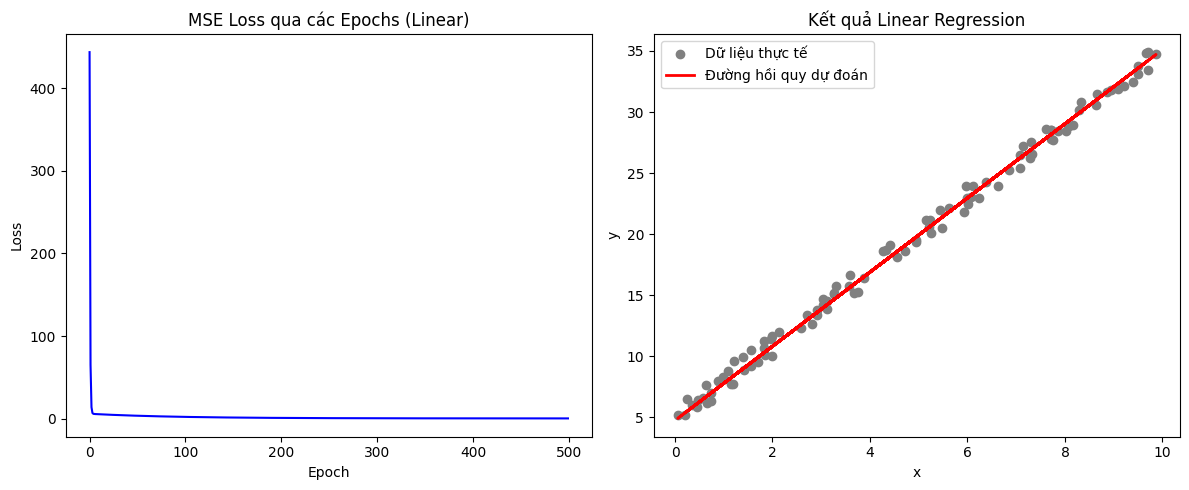

In [11]:
# 1.1 Hàm dự đoán
def predict_linear(x, w, b):
    return x * w + b

# 1.2 Hàm tính loss (MSE)
def mse_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

# 1.3 Huấn luyện bằng Gradient Descent
w_lin, b_lin = 0.0, 0.0  # Khởi tạo tham số
learning_rate_lin = 0.01
epochs_lin = 500
losses_lin = []

N = len(X_lin)

for epoch in range(epochs_lin):
    # Forward pass
    y_pred = predict_linear(X_lin, w_lin, b_lin)
    loss = mse_loss(y_lin, y_pred)
    losses_lin.append(loss)
    
    # Tính gradient
    dw = (2/N) * np.sum((y_pred - y_lin) * X_lin)
    db = (2/N) * np.sum(y_pred - y_lin)
    
    # Cập nhật w và b
    w_lin -= learning_rate_lin * dw
    b_lin -= learning_rate_lin * db
    
print(f"--- Kết quả Linear Regression ---")
print(f"w cuối cùng: {w_lin:.4f}")
print(f"b cuối cùng: {b_lin:.4f}")
print(f"Loss cuối cùng: {losses_lin[-1]:.4f}\n")

# 1.4 Trực quan hóa (Visualize)
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(losses_lin, color='blue')
plt.title("MSE Loss qua các Epochs (Linear)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Biểu đồ Kết quả dự đoán
plt.subplot(1, 2, 2)
plt.scatter(X_lin, y_lin, color='gray', label='Dữ liệu thực tế')
y_fit = predict_linear(X_lin, w_lin, b_lin)
plt.plot(X_lin, y_fit, color='red', linewidth=2, label='Đường hồi quy dự đoán')
plt.title("Kết quả Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.tight_layout()
plt.show()

## PHẦN 2: LOGISTIC REGRESSION
Phần này giải quyết bài toán phân loại nhị phân với các yêu cầu:
1. **Viết hàm Sigmoid và tính loss (2.0 điểm):** Xây dựng hàm kích hoạt Sigmoid $\sigma(z)$ ép giá trị về khoảng $(0, 1)$ và hàm tính mất mát $Binary Cross Entropy$ (BCE).
2. **Tính Gradient và Huấn luyện (1.5 điểm):** Áp dụng thuật toán Gradient Descent để tối ưu hóa $w$ và $b$, giúp phân tách hai lớp dữ liệu.

**Mục tiêu:** Loss giảm dần qua các epoch, chứng tỏ mô hình đang học cách phân tách hai tập dữ liệu (0 và 1) hiệu quả. Có in ra kết quả huấn luyện cuối cùng.

--- Kết quả Logistic Regression ---
w cuối cùng: 0.6640
b cuối cùng: -2.6696
Loss cuối cùng: 0.4385



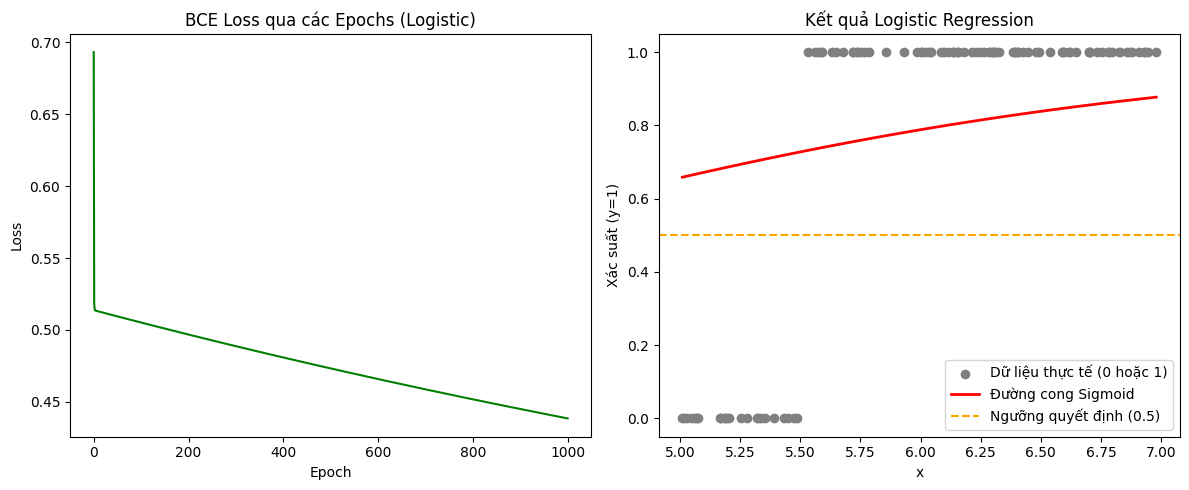

In [12]:
# 2.1 Hàm Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2.2 Hàm tính Loss
def bce_loss(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 2.3 Huấn luyện bằng Gradient Descent
w_log, b_log = 0.0, 0.0 
learning_rate_log = 0.1
epochs_log = 1000
losses_log = []

N_log = len(X_log)

for epoch in range(epochs_log):
    z = X_log * w_log + b_log
    y_pred = sigmoid(z)
    loss = bce_loss(y_log, y_pred)
    losses_log.append(loss)
    
    # Tính gradient
    dw = (1/N_log) * np.sum((y_pred - y_log) * X_log)
    db = (1/N_log) * np.sum(y_pred - y_log)
    
    # Cập nhật w và b
    w_log -= learning_rate_log * dw
    b_log -= learning_rate_log * db

print(f"--- Kết quả Logistic Regression ---")
print(f"w cuối cùng: {w_log:.4f}")
print(f"b cuối cùng: {b_log:.4f}")
print(f"Loss cuối cùng: {losses_log[-1]:.4f}\n")

# 2.4 Trực quan hóa (Visualize)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_log, color='green')
plt.title("BCE Loss qua các Epochs (Logistic)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.scatter(X_log, y_log, color='gray', label='Dữ liệu thực tế (0 hoặc 1)')
X_test = np.linspace(min(X_log), max(X_log), 100).reshape(-1, 1)
y_prob = sigmoid(X_test * w_log + b_log)
plt.plot(X_test, y_prob, color='red', linewidth=2, label='Đường cong Sigmoid')
plt.axhline(0.5, color='orange', linestyle='--', label='Ngưỡng quyết định (0.5)')
plt.title("Kết quả Logistic Regression")
plt.xlabel("x")
plt.ylabel("Xác suất (y=1)")
plt.legend()

plt.tight_layout()
plt.show()